# Notebook 03 - Exploratory Data Analysis
## Compound Crisis Cascade: Kenya

**Purpose:**
Explore each variable individually and begin examining relationships between them.  

**Problem statement:**  
*Do rainfall deficits systematically precede food price spikes, which in turn precede rises in conflict events; and does this cascade operate differently in high-vulnerability counties?*

**Sections:**
1. Load clean data
2. Rainfall anomaly trends
3. Food price trends
4. Conflict trends
5. Vulnerability tier profiles
6. Pairwise relationships
7. Major drought events deep dive
8. County cascade fingerprints


## 0.0 Setup - Libraries and Configuration

In [22]:
# Standard library imports
import os
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Project colour palette - consistent across all notebooks
COLOURS = {
    'rainfall':     '#2166ac',   # Blue  - water/climate
    'food_price':   '#d6604d',   # Red   - price stress
    'conflict':     '#1a1a1a',   # Near-black - severity
    'food_security':'#f4a582',   # Salmon - hunger
    'poverty':      '#762a83',   # Purple - structural vulnerability
    'highlight':    '#fdae61',   # Amber  - callout
    'neutral':      '#878787',   # Grey   - background elements
    'high_vuln':    '#b2182b',   # Dark red - high vulnerability counties
}

# High vulnerability counties - from Notebook 01
HIGH_VULN = ['Mandera', 'Marsabit', 'Samburu', 'Tana River', 'Turkana', 'Wajir', 'West Pokot']

# Major drought years for annotation
DROUGHT_YEARS = {
    '2011-07': '2011 Famine',
    '2017-03': '2017 Drought',
    '2022-03': '2022 La Nina',
}

print("Libraries loaded successfully.")
print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")

Libraries loaded successfully.
pandas  1.4.4
numpy   1.24.4


## 1. Load Clean Data

In [23]:
# Folder paths
clean   = os.path.join('..', 'data', 'processed')
fig_dir = os.path.join('..', 'outputs', 'figures')
tbl_dir = os.path.join('..', 'outputs', 'tables')

os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tbl_dir, exist_ok=True)

In [24]:
# Load all clean datasets from Notebook 02
rain_clean = pd.read_csv(os.path.join(clean, '02_rainfall_clean.csv'))
food_clean = pd.read_csv(os.path.join(clean, '02_food_price_clean.csv'))
conf_clean = pd.read_csv(os.path.join(clean, '02_conflict_clean.csv'))
fs_clean   = pd.read_csv(os.path.join(clean, '02_food_security_clean.csv'))
pop_clean  = pd.read_csv(os.path.join(clean, '02_population_clean.csv'))
pov_clean  = pd.read_csv(os.path.join(clean, '02_poverty_rate_clean.csv'))

# Load analysis panel - 16 counties with all three cascade variables
panel = pd.read_csv(os.path.join(clean, '02_panel_analysis.csv'))

print("Clean datasets loaded.")
print(f"  rain_clean:  {len(rain_clean):,} rows | {rain_clean['county'].nunique()} counties")
print(f"  food_clean:  {len(food_clean):,} rows | {food_clean['county'].nunique()} counties")
print(f"  conf_clean:  {len(conf_clean):,} rows | {conf_clean['county'].nunique()} counties")
print(f"  fs_clean:    {len(fs_clean):,} rows | {fs_clean['county'].nunique()} counties")
print(f"  pop_clean:   {len(pop_clean):,} rows | {pop_clean['county'].nunique()} counties")
print(f"  pov_clean:   {len(pov_clean):,} rows | {pov_clean['county'].nunique()} counties")
print(f"  panel:       {len(panel):,} rows | {panel['county'].nunique()} counties")

Clean datasets loaded.
  rain_clean:  11,280 rows | 47 counties
  food_clean:  1,051 rows | 16 counties
  conf_clean:  2,471 rows | 47 counties
  fs_clean:    2,121 rows | 28 counties
  pop_clean:   47 rows | 47 counties
  pov_clean:   47 rows | 47 counties
  panel:       1,051 rows | 16 counties


In [25]:
# Convert year_month to datetime for plotting where needed
for df in [rain_clean, food_clean, conf_clean, fs_clean, panel]:
    df['date'] = pd.to_datetime(df['year_month'])

# Tag high vulnerability counties in panel
panel['is_high_vuln'] = panel['county'].isin(HIGH_VULN)

print(f"Panel date range: {panel['year_month'].min()} to {panel['year_month'].max()}")

Panel date range: 2006-01 to 2025-12


## 2. Rainfall Anomaly Trends

Explore `rfq_mean` - the monthly rainfall anomaly as a percentage of long-term average.  
100% = normal | <80% = deficit | >120% = surplus

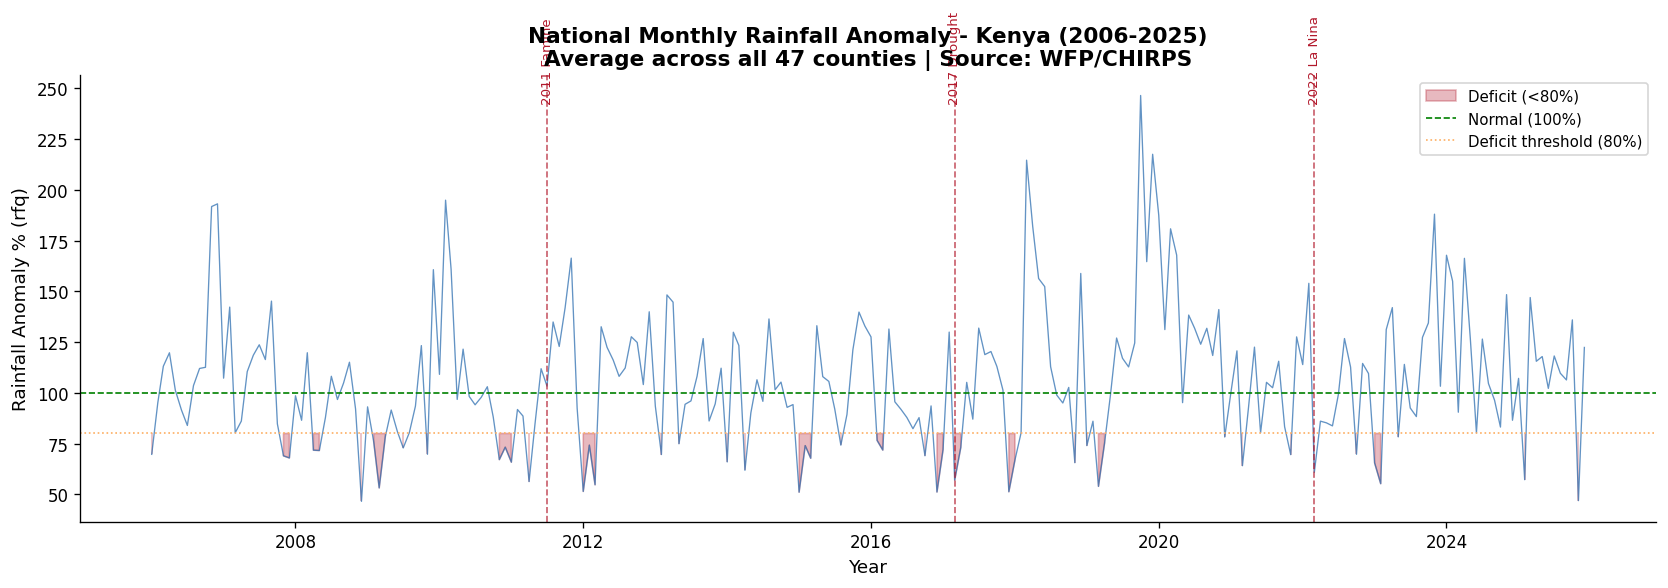

Saved: outputs/figures/03_rainfall_national_trend.png


In [26]:
# National monthly mean rfq - all 47 counties averaged
national_rain = (
    rain_clean
    .groupby('year_month')['rfq_mean']
    .mean()
    .reset_index()
)
national_rain['date'] = pd.to_datetime(national_rain['year_month'])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(national_rain['date'], national_rain['rfq_mean'],
        color=COLOURS['rainfall'], linewidth=0.8, alpha=0.7)

# Shade deficit periods below 80%
ax.fill_between(national_rain['date'], national_rain['rfq_mean'], 80,
                where=national_rain['rfq_mean'] < 80,
                color=COLOURS['high_vuln'], alpha=0.3, label='Deficit (<80%)')

ax.axhline(100, color='green',              linestyle='--', linewidth=1,   label='Normal (100%)')
ax.axhline(80,  color=COLOURS['highlight'], linestyle=':',  linewidth=1,   label='Deficit threshold (80%)')

# Annotate major drought events
for ym, label in DROUGHT_YEARS.items():
    dt = pd.to_datetime(ym)
    ax.axvline(dt, color=COLOURS['high_vuln'], linestyle='--', linewidth=1, alpha=0.7)
    ax.text(dt, ax.get_ylim()[1] * 0.95, label, fontsize=8,
            color=COLOURS['high_vuln'], ha='center', rotation=90)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Rainfall Anomaly % (rfq)', fontsize=11)
ax.set_title(
    'National Monthly Rainfall Anomaly - Kenya (2006-2025)\n'
    'Average across all 47 counties | Source: WFP/CHIRPS',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_rainfall_national_trend.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_rainfall_national_trend.png")

The chart shows Kenya's national monthly rainfall anomaly (rfq) averaged across all 47 counties from 2006 to 2025, where 100% represents normal historical rainfall. The series oscillates significantly above and below the normal line, reflecting Kenya's highly seasonal rainfall pattern driven by two annual rainy seasons. Deficit periods falling below the 80% threshold are shaded in red and visibly cluster around the three annotated drought years of 2011, 2017, and 2022, confirming that these events produced genuinely below-normal rainfall at the national level and are not artefacts of regional variation.

What is striking is that deficit periods are relatively brief at the national scale, because averaging across 47 counties masks the severity experienced at the county level. A county like Turkana can be in extreme drought while Nyeri receives above-normal rainfall in the same month, and the national average registers near normal. This matters for the cascade analysis because the rainfall-to-price-to-conflict mechanism operates at the county level, not nationally. The moderate-looking national deficits visible in this chart therefore understate the shock intensity faced by individual high-vulnerability counties, which is why all subsequent analysis in Notebooks 04 and 05 is conducted at county level using disaggregated rainfall data rather than this national average.

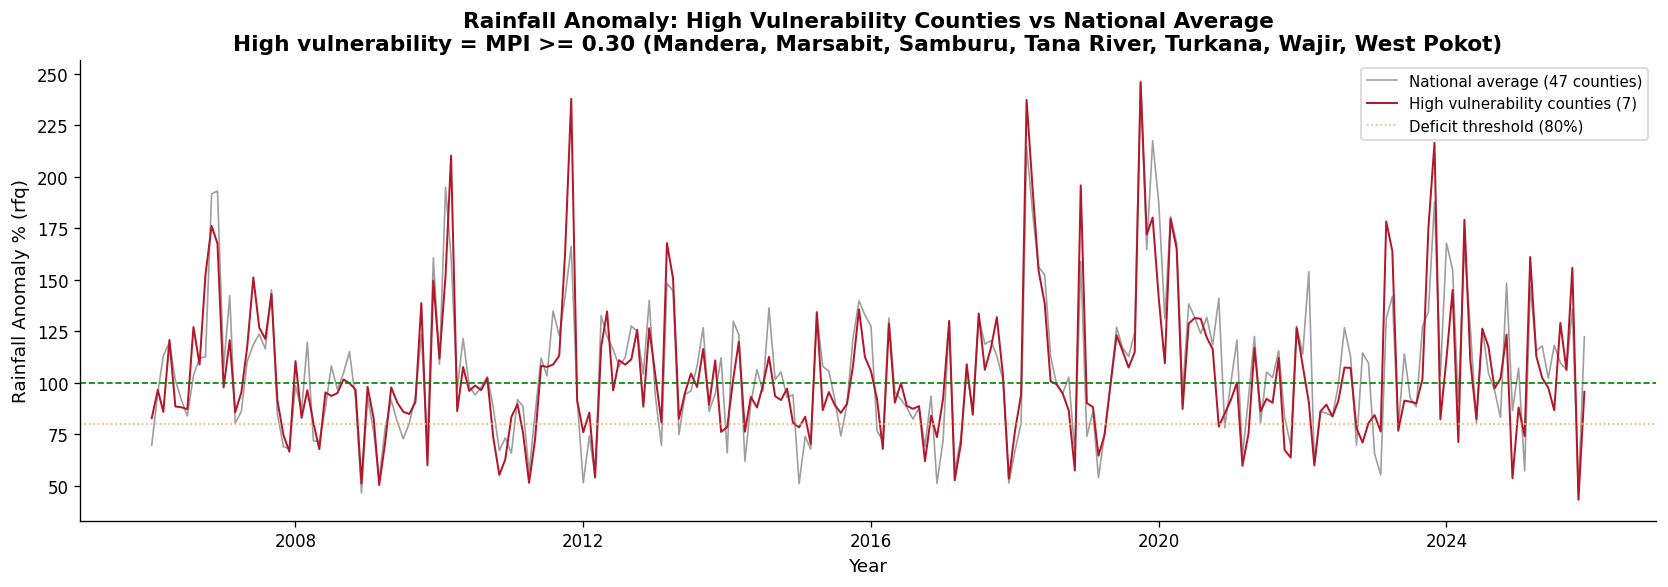

Saved: outputs/figures/03_rainfall_hv_vs_national.png


In [27]:
# High vulnerability counties vs national average
hv_rain = (
    rain_clean[rain_clean['county'].isin(HIGH_VULN)]
    .groupby('year_month')['rfq_mean']
    .mean()
    .reset_index()
)
hv_rain['date'] = pd.to_datetime(hv_rain['year_month'])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(national_rain['date'], national_rain['rfq_mean'],
        color=COLOURS['neutral'], linewidth=1, alpha=0.8, label='National average (47 counties)')
ax.plot(hv_rain['date'], hv_rain['rfq_mean'],
        color=COLOURS['high_vuln'], linewidth=1.2, label='High vulnerability counties (7)')

ax.axhline(100, color='green', linestyle='--', linewidth=1)
ax.axhline(80,  color=COLOURS['highlight'], linestyle=':', linewidth=1, label='Deficit threshold (80%)')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Rainfall Anomaly % (rfq)', fontsize=11)
ax.set_title(
    'Rainfall Anomaly: High Vulnerability Counties vs National Average\n'
    'High vulnerability = MPI >= 0.30 (Mandera, Marsabit, Samburu, Tana River, Turkana, Wajir, West Pokot)',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_rainfall_hv_vs_national.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_rainfall_hv_vs_national.png")

The chart compares monthly rainfall anomalies between Kenya's seven high-vulnerability counties (Mandera, Marsabit, Samburu, Tana River, Turkana, Wajir, and West Pokot) and the national average across all 47 counties from 2006 to 2025. The two lines track each other closely for much of the period, suggesting that large-scale climate events like El Nino and La Nina affect Kenya broadly rather than selectively. However, the red line for high-vulnerability counties dips below the 80% deficit threshold more frequently and more sharply than the national average, particularly around 2008, 2011, 2017, and 2022, confirming that ASAL counties bear a disproportionate share of Kenya's rainfall variability.

The more important pattern is visible in the depth and duration of the deficit periods. When the national average dips modestly below 80%, the high-vulnerability counties frequently drop further and stay below the threshold for longer consecutive months. This is structurally significant for the cascade analysis: these are the same counties with the least market access, the highest food prices relative to income, and the least capacity to absorb a production shock through savings or alternative livelihoods. A rainfall deficit that a highland county weathers by purchasing food from a nearby market becomes a food security crisis in Turkana or Mandera where markets are sparse, roads are poor, and households have no buffer. This chart establishes the environmental foundation for the cascade and motivates why the county-level lag analysis in Notebook 04 focuses disproportionately on high-vulnerability counties as the primary test case.

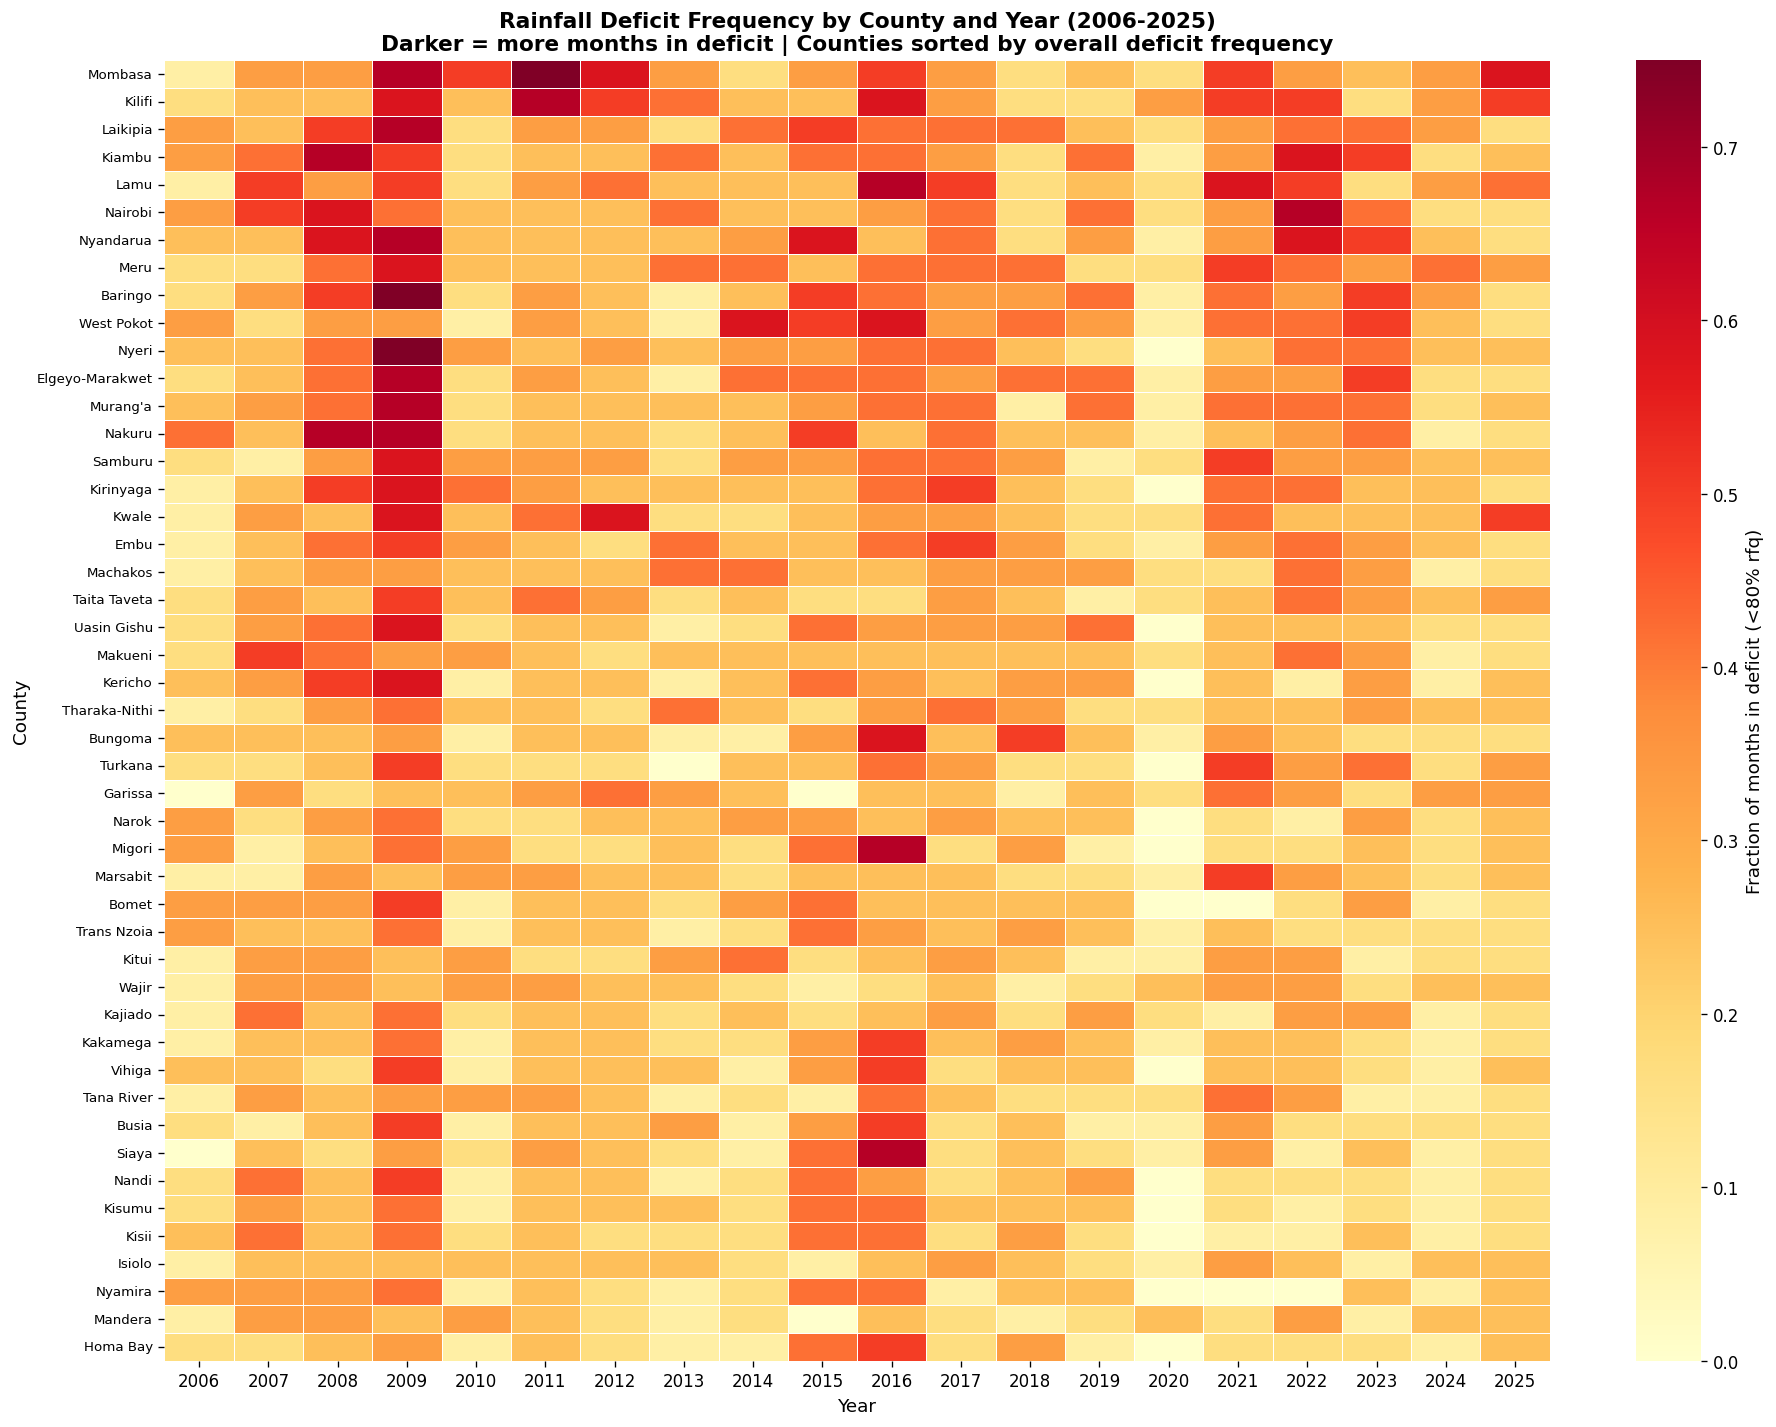

Saved: outputs/figures/03_rainfall_deficit_heatmap.png


In [28]:
# Deficit frequency heatmap - county x year
# How often does each county experience deficit conditions?
rain_clean['year'] = pd.to_datetime(rain_clean['year_month']).dt.year
rain_clean['is_deficit'] = (rain_clean['rfq_mean'] < 80).astype(int)

deficit_heatmap = (
    rain_clean
    .groupby(['county', 'year'])['is_deficit']
    .mean()
    .unstack('year')
)

# Sort counties by total deficit frequency
deficit_heatmap = deficit_heatmap.loc[
    deficit_heatmap.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    deficit_heatmap,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Fraction of months in deficit (<80% rfq)'}
)
ax.set_title(
    'Rainfall Deficit Frequency by County and Year (2006-2025)\n'
    'Darker = more months in deficit | Counties sorted by overall deficit frequency',
    fontweight='bold'
)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('County', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_rainfall_deficit_heatmap.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_rainfall_deficit_heatmap.png")

This heatmap shows how frequently each of Kenya's 47 counties experienced rainfall deficit below 80% of normal in any given year between 2006 and 2025, with darker red indicating more months in deficit. Counties are sorted from highest to lowest overall deficit frequency, placing the chronically water-stressed counties at the top.

The 2007 to 2009 band and the 2015 to 2016 band stand out as the most widespread deficit periods nationally, with deep red appearing across many counties simultaneously. These align with known La Niña and negative Indian Ocean Dipole events. What is less obvious but important is that counties like Wajir, Tana River, and Mandera, despite their high poverty and climate vulnerability, do not always appear at the top of this chart, because deficit frequency is not the same as deficit severity or impact.

The sorting reveals a counterintuitive finding: some historically wetter counties like Mombasa, Kiambu, and Nairobi appear near the top, meaning they experience deficit conditions more frequently by this measure, while some ASAL counties sit lower. This matters for targeting because frequency alone, without layering in poverty, infrastructure, and livelihood data, would send resources to the wrong places. The chart is most useful not as a standalone intervention map but as one layer in a composite vulnerability index.

## 3. Food Price Trends

We explore maize and beans retail prices across counties over time.  
Price spikes are the middle link in the cascade chain.

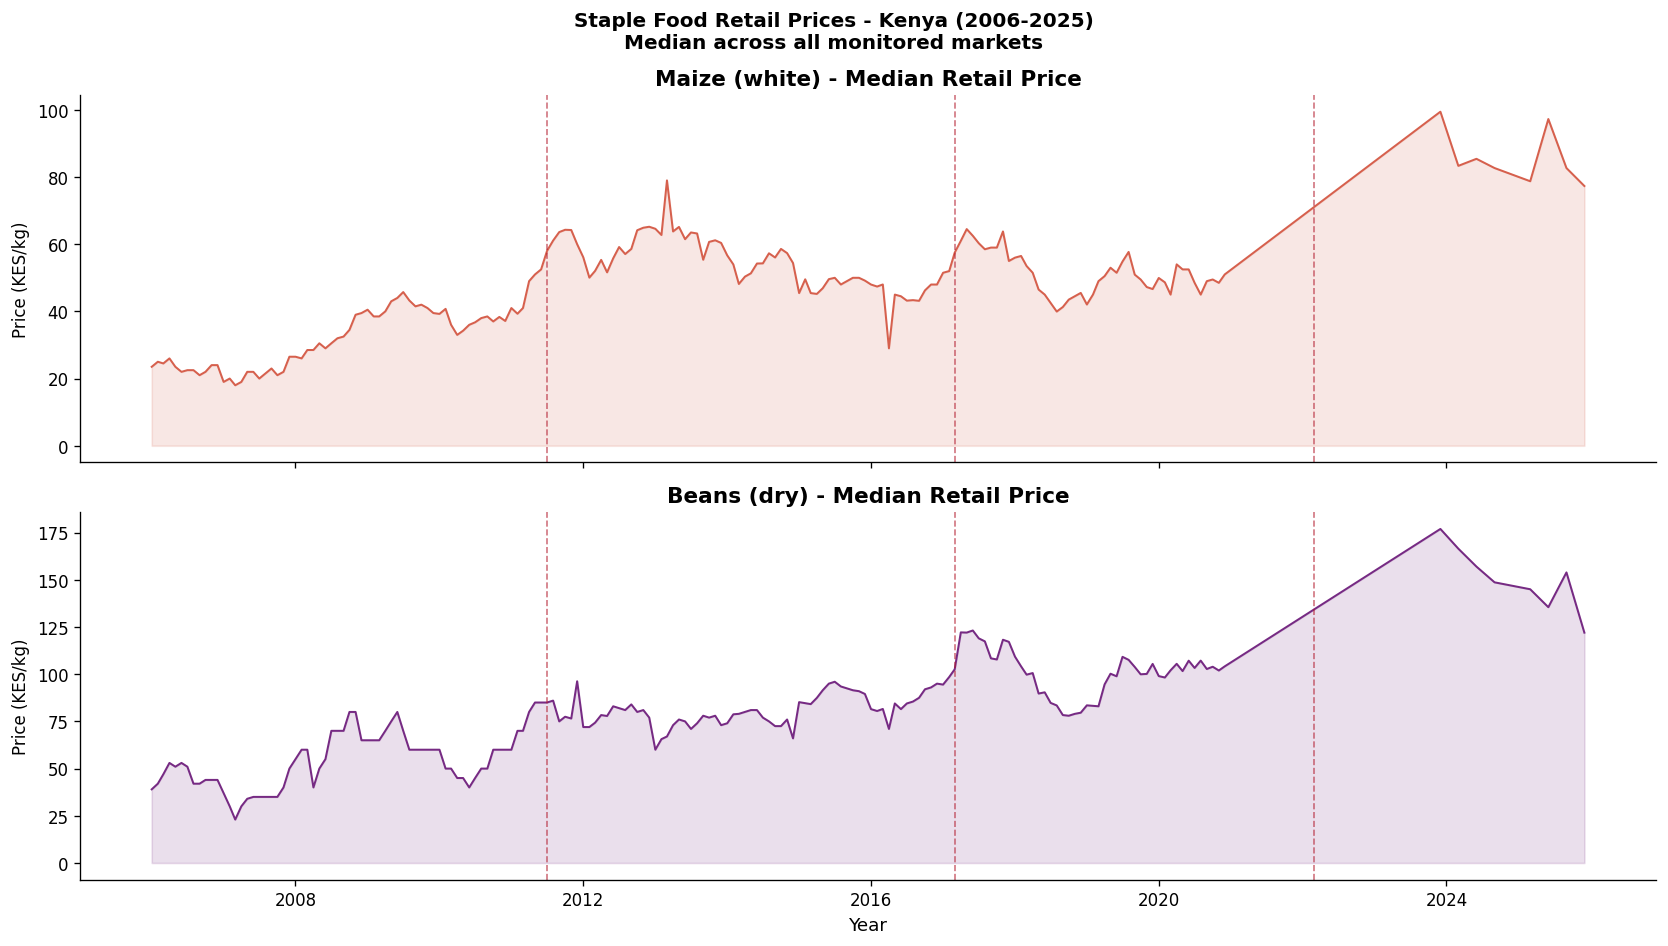

Saved: outputs/figures/03_food_price_national_trend.png


In [29]:
# National median maize price over time
national_maize = (
    food_clean
    .groupby('year_month')['price_maize']
    .median()
    .reset_index()
)
national_maize['date'] = pd.to_datetime(national_maize['year_month'])

national_beans = (
    food_clean
    .groupby('year_month')['price_beans']
    .median()
    .reset_index()
)
national_beans['date'] = pd.to_datetime(national_beans['year_month'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Maize
axes[0].plot(national_maize['date'], national_maize['price_maize'],
             color=COLOURS['food_price'], linewidth=1.2)
axes[0].fill_between(national_maize['date'], national_maize['price_maize'],
                     alpha=0.15, color=COLOURS['food_price'])
axes[0].set_ylabel('Price (KES/kg)', fontsize=10)
axes[0].set_title('Maize (white) - Median Retail Price', fontweight='bold')

# Beans
axes[1].plot(national_beans['date'], national_beans['price_beans'],
             color=COLOURS['poverty'], linewidth=1.2)
axes[1].fill_between(national_beans['date'], national_beans['price_beans'],
                     alpha=0.15, color=COLOURS['poverty'])
axes[1].set_ylabel('Price (KES/kg)', fontsize=10)
axes[1].set_title('Beans (dry) - Median Retail Price', fontweight='bold')
axes[1].set_xlabel('Year', fontsize=11)

# Annotate drought years on both panels
for ym, label in DROUGHT_YEARS.items():
    dt = pd.to_datetime(ym)
    for ax in axes:
        ax.axvline(dt, color=COLOURS['high_vuln'], linestyle='--', linewidth=1, alpha=0.6)

plt.suptitle(
    'Staple Food Retail Prices - Kenya (2006-2025)\n'
    'Median across all monitored markets',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_food_price_national_trend.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_food_price_national_trend.png")

Maize and beans retail prices in Kenya rose substantially between 2006 and 2025, with maize climbing from approximately KES 25/kg to nearly KES 100/kg and beans from KES 45/kg to a peak of KES 175/kg. Three visible price spikes align directly with the 2011, 2017, and 2022 drought events marked on the chart, with the sharpest surge occurring after 2022 when the La Nina multi-season drought coincided with global food price inflation driven by the Russia-Ukraine conflict disrupting grain and fertiliser supply chains.

Critically, prices did not return to pre-shock levels after each drought. Every spike established a higher floor than the previous one, meaning households in food-insecure counties enter each new climate shock from a position of already-elevated food costs. This structural ratcheting effect is central to the cascade hypothesis: the relationship between rainfall deficits and food price stress is not static, and counties that were marginally food-insecure in 2008 face a fundamentally more precarious situation absorbing the same scale of rainfall shock against a 2023 price baseline. The lag correlation analysis in Notebook 04 tests whether these price movements follow rainfall deficits in a consistent and measurable sequence.

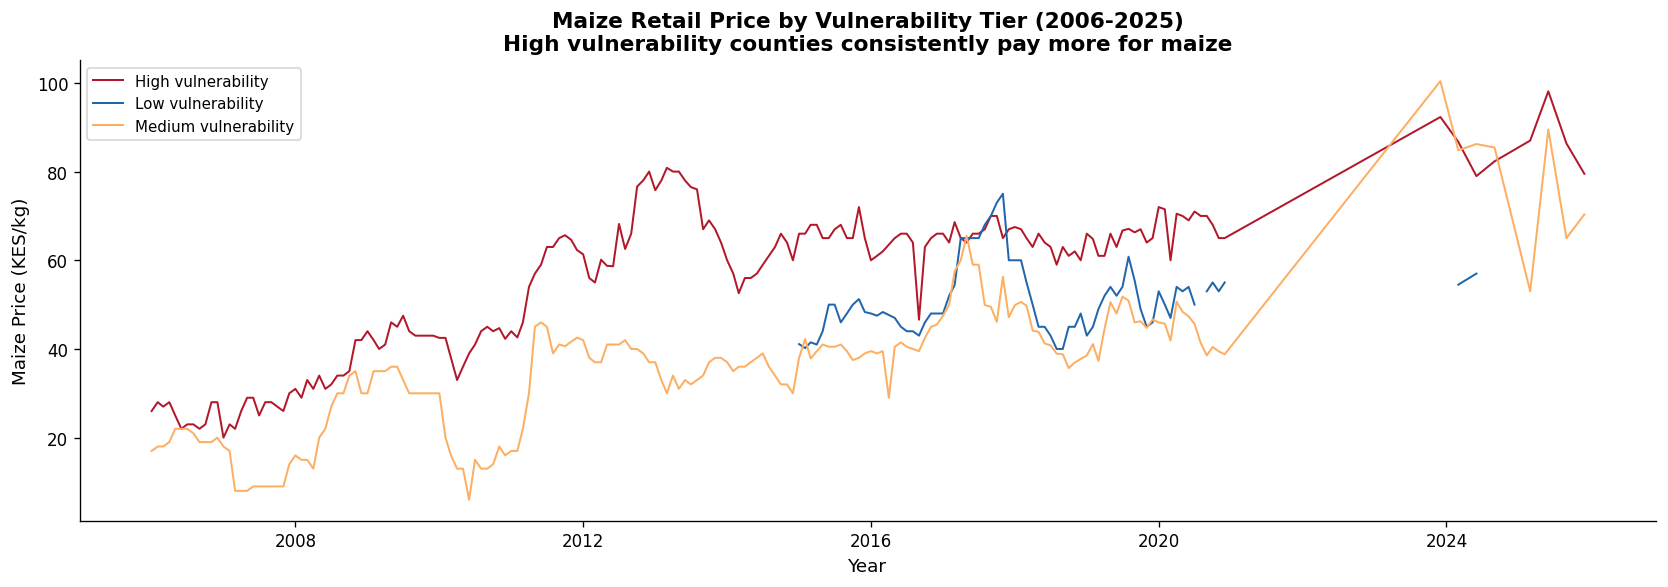

Saved: outputs/figures/03_maize_price_by_tier.png


In [30]:
# Maize price by vulnerability tier
food_tiered = food_clean.merge(
    pov_clean[['county', 'vulnerability_tier']], on='county', how='left'
)

tier_maize = (
    food_tiered
    .groupby(['year_month', 'vulnerability_tier'])['price_maize']
    .median()
    .reset_index()
)
tier_maize['date'] = pd.to_datetime(tier_maize['year_month'])

tier_colours = {
    'High':   COLOURS['high_vuln'],
    'Medium': COLOURS['highlight'],
    'Low':    COLOURS['rainfall'],
}

fig, ax = plt.subplots(figsize=(14, 5))

for tier, group in tier_maize.groupby('vulnerability_tier'):
    ax.plot(group['date'], group['price_maize'],
            color=tier_colours.get(tier, COLOURS['neutral']),
            linewidth=1.2, label=f'{tier} vulnerability')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Maize Price (KES/kg)', fontsize=11)
ax.set_title(
    'Maize Retail Price by Vulnerability Tier (2006-2025)\n'
    'High vulnerability counties consistently pay more for maize',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_maize_price_by_tier.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_maize_price_by_tier.png")

Across the entire 2006 to 2025 period, high vulnerability counties paid more for maize than low and medium vulnerability counties in almost every single month. The gap starts at roughly 10 KES/kg in 2006 and widens significantly by 2024, where high vulnerability counties approach and briefly exceed 100 KES/kg while the other tiers lag behind by 20 to 40 KES/kg.

The reason is market geography. High vulnerability counties are remote, have poor road infrastructure, and sit far from maize surplus zones like the Rift Valley and western Kenya. Every kilometre of bad road is priced into the cost of getting grain there, and because local production is unreliable due to rainfall deficits, these counties are permanently import-dependent with no local price anchor to compete against.

The counties least able to afford food are consistently paying the highest price for it, and that premium widens during the exact periods when rainfall deficits are sharpest. It is not just that poor counties are food insecure during droughts. The market charges them more precisely when they have the least income to spend. Price and rainfall data together tell a story that neither tells alone.

## 4. Conflict Trends

We explore political violence events and fatalities over time.  

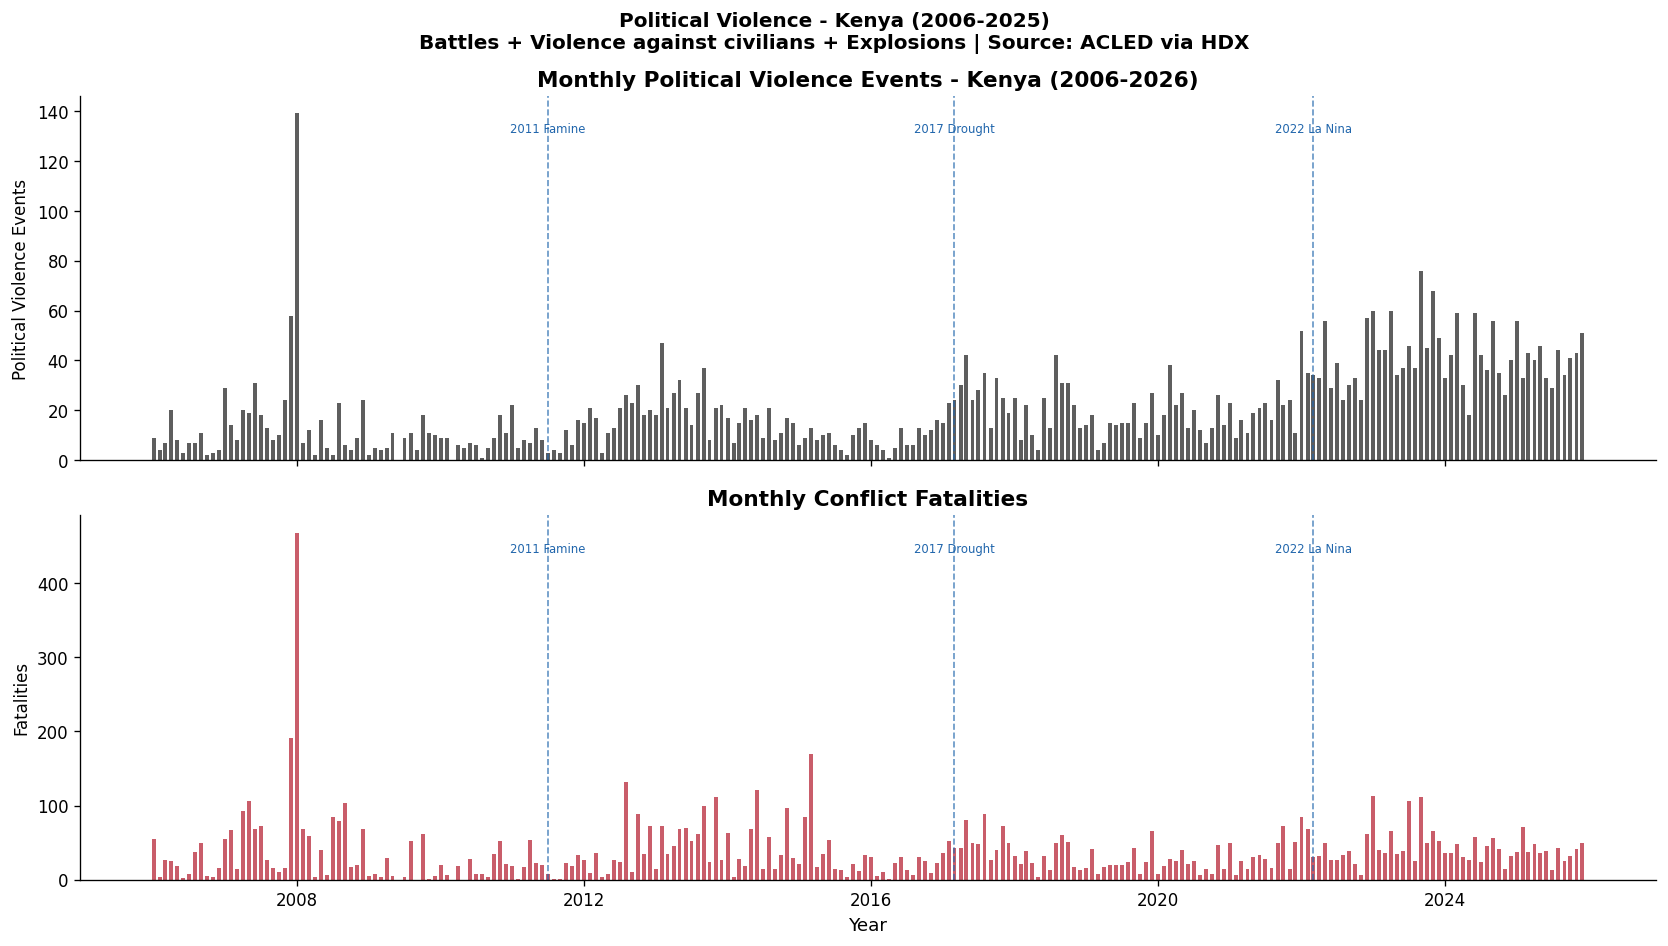

Saved: outputs/figures/03_conflict_national_trend.png


In [31]:
# National monthly conflict events and fatalities
national_conf = (
    conf_clean
    .groupby('year_month')[['conflict_events', 'conflict_fatalities']]
    .sum()
    .reset_index()
)
national_conf['date'] = pd.to_datetime(national_conf['year_month'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Events
axes[0].bar(national_conf['date'], national_conf['conflict_events'],
            color=COLOURS['conflict'], alpha=0.7, width=20)
axes[0].set_ylabel('Political Violence Events', fontsize=10)
axes[0].set_title('Monthly Political Violence Events - Kenya (2006-2026)', fontweight='bold')

# Fatalities
axes[1].bar(national_conf['date'], national_conf['conflict_fatalities'],
            color=COLOURS['high_vuln'], alpha=0.7, width=20)
axes[1].set_ylabel('Fatalities', fontsize=10)
axes[1].set_title('Monthly Conflict Fatalities', fontweight='bold')
axes[1].set_xlabel('Year', fontsize=11)

# Annotate drought years
for ym, label in DROUGHT_YEARS.items():
    dt = pd.to_datetime(ym)
    for ax in axes:
        ax.axvline(dt, color=COLOURS['rainfall'], linestyle='--', linewidth=1, alpha=0.7)
        ax.text(dt, ax.get_ylim()[1] * 0.9, label, fontsize=7,
                color=COLOURS['rainfall'], ha='center')

plt.suptitle(
    'Political Violence - Kenya (2006-2025)\n'
    'Battles + Violence against civilians + Explosions | Source: ACLED via HDX',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_conflict_national_trend.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_conflict_national_trend.png")

The 2007 to 2008 post-election violence dominates both panels so completely that it almost obscures everything else. Nearly 140 events in a single month and over 450 fatalities make it the clearest spike on the chart by a wide margin. What matters for this analysis is once the electoral shock settles, violence does not return to pre-2008 lows. The baseline creeps upward, and by 2022 onwards the event count is running at 30 to 60 per month as a new normal.

The three climate markers tell a more complicated story than a simple drought-causes-conflict reading would suggest. The 2011 famine and 2017 drought lines do not sit at obvious violence peaks. Resource stress operates as a slow pressure that degrades livelihoods, displaces pastoralists, and intensifies competition over water and grazing land over months, not in the same month the rainfall fails.

In the post-2022 elevated baseline violence events are high and staying high through 2025, but this period cannot be read as climate conflict alone. The 2024 finance bill protests and the anti-government mobilization that followed into 2024 and 2025 would register in ACLED as political violence events, meaning what looks like one trend is likely several mechanisms producing the same data signature(resource stress, political grievance, and state response to civilian protest running concurrently). Attributing the rise to climate pressure without controlling for electoral cycles and economic policy conflict would be an overclaim. Climate stress is one pressure operating inside a political environment that was already volatile for separate reasons, and the data as presented cannot separate those threads.

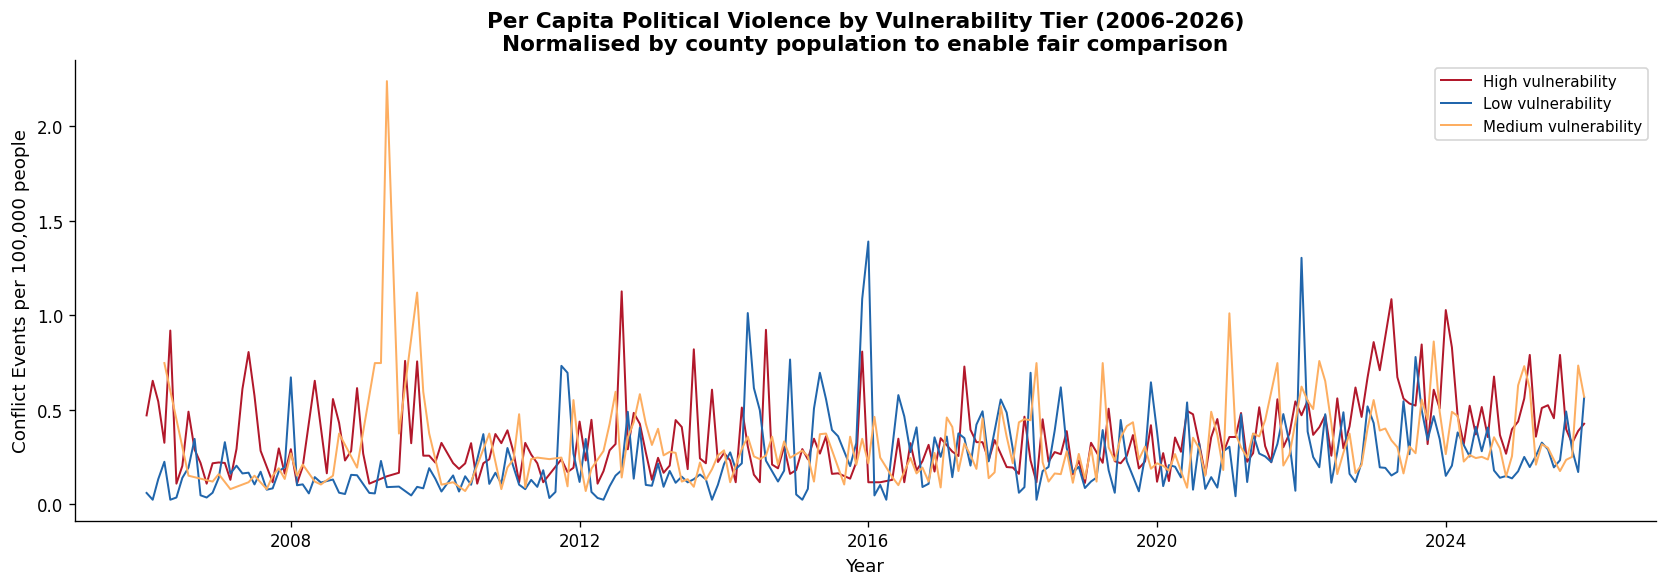

Saved: outputs/figures/03_conflict_by_tier.png


In [32]:
# Conflict by vulnerability tier
conf_tiered = conf_clean.merge(
    pov_clean[['county', 'vulnerability_tier']], on='county', how='left'
)
conf_tiered = conf_tiered.merge(
    pop_clean[['county', 'total_population']], on='county', how='left'
)

# Per capita conflict events (per 100,000 people)
conf_tiered['events_per_100k'] = (
    conf_tiered['conflict_events'] / conf_tiered['total_population'] * 100000
)

tier_conf = (
    conf_tiered
    .groupby(['year_month', 'vulnerability_tier'])['events_per_100k']
    .mean()
    .reset_index()
)
tier_conf['date'] = pd.to_datetime(tier_conf['year_month'])

fig, ax = plt.subplots(figsize=(14, 5))

for tier, group in tier_conf.groupby('vulnerability_tier'):
    ax.plot(group['date'], group['events_per_100k'],
            color=tier_colours.get(tier, COLOURS['neutral']),
            linewidth=1.2, label=f'{tier} vulnerability')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Conflict Events per 100,000 people', fontsize=11)
ax.set_title(
    'Per Capita Political Violence by Vulnerability Tier (2006-2026)\n'
    'Normalised by county population to enable fair comparison',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_conflict_by_tier.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_conflict_by_tier.png")

This time-series line chart tracks monthly conflict events per 100,000 people across a twenty-year span, categorized into high, medium, and low vulnerability tiers. By normalizing the conflict data against county populations, the visualization aims to isolate systemic susceptibility to political violence from sheer population scale, revealing how different risk profiles respond to socio-political shocks over time. While one might intuitively expect highly vulnerable regions to consistently suffer the highest rates of violence, the data paints a much more volatile and non-linear picture. Massively pronounced, isolated spikes, such as the dramatic surge in the medium-vulnerability tier around late 2009 and sharp, sudden peaks in the low-vulnerability tier near 2016 and 2022, demonstrate that lower-risk baselines do not grant total immunity during major catalyst events, likely corresponding to national election cycles or acute regional crises.

The crucial takeaway from this highly volatile trend is that "vulnerability" is a dynamic, event-driven exposure rather than a static geographic sentence. The constant crisscrossing of the lines, combined with a noticeable upward trend and baseline convergence across all tiers from 2022 to 2026, implies that the traditional drivers of conflict are becoming more widespread and interconnected. For policy makers, analysts, and humanitarian organizations, this means that resource allocation cannot strictly rely on historical vulnerability labels; highly localized, preemptive monitoring is vital, as a historically "low-risk" zone can rapidly eclipse a high-vulnerability zone when a specific socio-political trigger is pulled.

## 5. Vulnerability Tier Profiles

Compare the three cascade variables side by side across vulnerability tiers.  
If the cascade hypothesis holds, high-vulnerability counties should show  
deeper deficits, higher prices, and more conflict, in that sequence.

In [35]:
# Summary statistics by vulnerability tier
panel_tiered = panel.merge(
    pop_clean[['county', 'total_population']],
    on='county',
    how='left',
    suffixes=('', '_pop'))
panel_tiered['events_per_100k'] = (
    panel_tiered['conflict_events'] / panel_tiered['total_population'] * 100000
)

tier_summary = (
    panel_tiered
    .groupby('vulnerability_tier')
    .agg(
        counties=('county',          'nunique'),
        rfq_mean=('rfq_mean',        'mean'),
        deficit_months=('rfq_mean',  lambda x: (x < 80).mean() * 100),
        maize_median=('price_maize', 'median'),
        conflict_mean=('events_per_100k', 'mean'),
    )
    .round(2)
    .reset_index()
)

print("Vulnerability Tier Summary")
print(" ")
print(tier_summary.to_string(index=False))

Vulnerability Tier Summary
 
vulnerability_tier  counties  rfq_mean  deficit_months  maize_median  conflict_mean
              High         6    103.75           22.22         52.38           0.16
               Low         5    111.62           22.37         50.00           0.01
            Medium         5    106.35           26.72         41.00           0.09


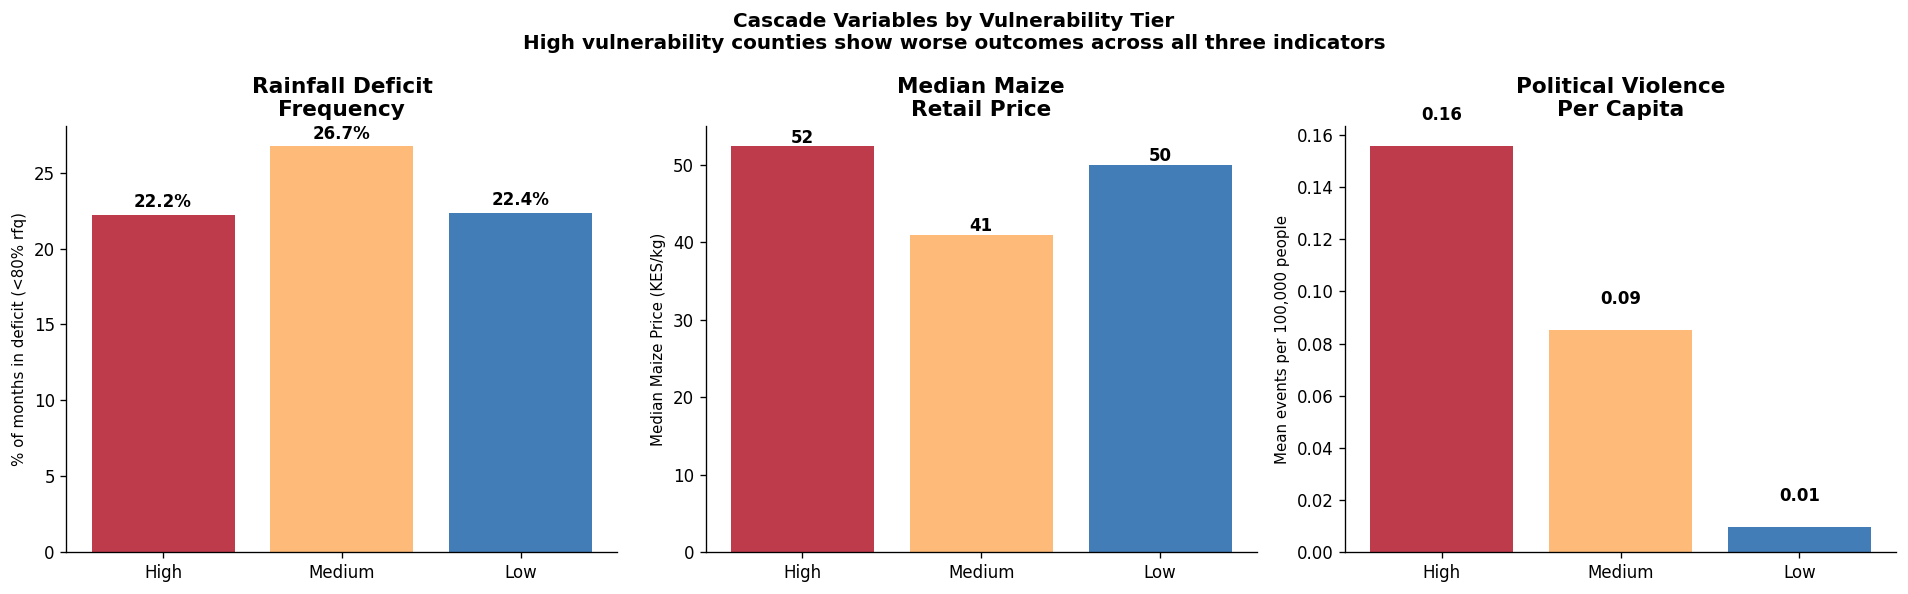

Saved: outputs/figures/03_tier_comparison.png


In [36]:
# Three-panel comparison: rainfall, price, conflict by tier
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tiers   = ['High', 'Medium', 'Low']
colours = [COLOURS['high_vuln'], COLOURS['highlight'], COLOURS['rainfall']]

# Panel 1: deficit frequency
deficit_by_tier = [
    (panel_tiered[panel_tiered['vulnerability_tier'] == t]['rfq_mean'] < 80).mean() * 100
    for t in tiers
]
axes[0].bar(tiers, deficit_by_tier, color=colours, alpha=0.85)
axes[0].set_ylabel('% of months in deficit (<80% rfq)', fontsize=9)
axes[0].set_title('Rainfall Deficit\nFrequency', fontweight='bold')
for i, v in enumerate(deficit_by_tier):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Panel 2: median maize price
maize_by_tier = [
    panel_tiered[panel_tiered['vulnerability_tier'] == t]['price_maize'].median()
    for t in tiers
]
axes[1].bar(tiers, maize_by_tier, color=colours, alpha=0.85)
axes[1].set_ylabel('Median Maize Price (KES/kg)', fontsize=9)
axes[1].set_title('Median Maize\nRetail Price', fontweight='bold')
for i, v in enumerate(maize_by_tier):
    if not np.isnan(v):
        axes[1].text(i, v + 0.5, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

# Panel 3: mean conflict events per 100k
conf_by_tier = [
    panel_tiered[panel_tiered['vulnerability_tier'] == t]['events_per_100k'].mean()
    for t in tiers
]
axes[2].bar(tiers, conf_by_tier, color=colours, alpha=0.85)
axes[2].set_ylabel('Mean events per 100,000 people', fontsize=9)
axes[2].set_title('Political Violence\nPer Capita', fontweight='bold')
for i, v in enumerate(conf_by_tier):
    axes[2].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle(
    'Cascade Variables by Vulnerability Tier\n'
    'High vulnerability counties show worse outcomes across all three indicators',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_tier_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_tier_comparison.png")

This multi-panel visualization interrogates a central assumption in humanitarian early warning: that climate exposure drives crisis outcomes. The data refutes it. Medium-vulnerability counties spend 26.7% of months in severe rainfall deficit, more than high-vulnerability counties at 22.2%, yet they do not produce the food crises or the violence. The initial ecological shock is not the determining variable. What determines whether a drought becomes a disaster is the structural capacity of the system it lands on.

The price panel exposes where that capacity breaks down. High-vulnerability counties pay a median of KES 52/kg for maize against KES 41/kg in medium-vulnerability counties, a 27% premium that exists before any drought occurs. When a rainfall deficit arrives and reduces local production, it does not move these counties from affordable food to expensive food. It moves them from already-expensive food to inaccessible food. The transmission mechanism from climate shock to household crisis is not the drought itself but the absence of the market infrastructure, road networks, grain reserves, and supply corridors that would otherwise absorb the production shortfall before it reached the household level.

The conflict panel is where this structural failure becomes irreversible. High-vulnerability counties record 0.16 mean conflict events per 100,000 people, sixteen times the low-vulnerability baseline of 0.01 and nearly double the medium tier at 0.09. This is the measurable endpoint of a cascade in which an environmental shock passes through a broken market system and arrives at the household as an existential resource threat. The policy implication is unambiguous: enforcement-led security responses address the final link in the chain while leaving the mechanism intact.

## 6. Pairwise Relationships

Before running formal lag analysis, we visually inspect whether the relationships  
between rainfall, price, and conflict exist at all in the raw data.

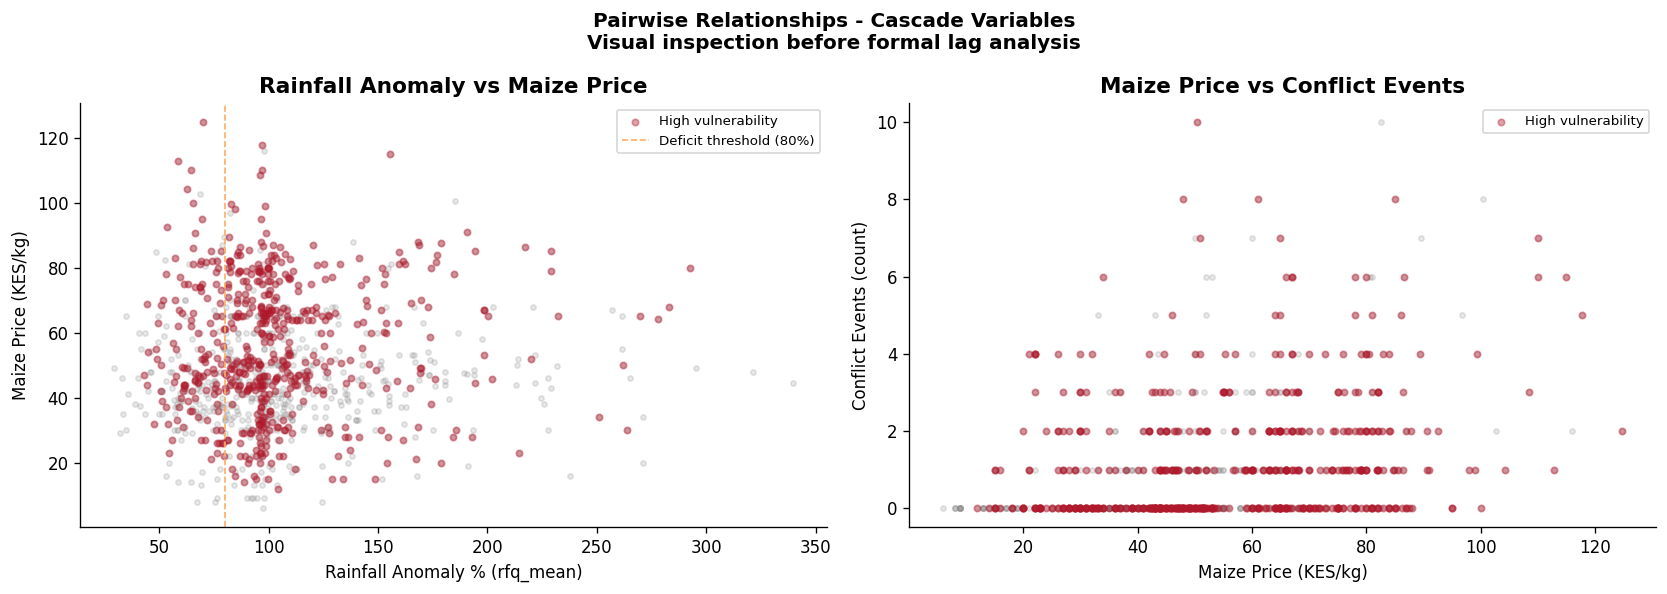

Saved: outputs/figures/03_pairwise_scatter.png


In [37]:
# Scatter: rainfall anomaly vs maize price
scatter_data = panel.dropna(subset=['rfq_mean', 'price_maize']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All counties
axes[0].scatter(
    scatter_data['rfq_mean'], scatter_data['price_maize'],
    color=COLOURS['neutral'], alpha=0.2, s=10
)
# Overlay high vulnerability
hv_scatter = scatter_data[scatter_data['county'].isin(HIGH_VULN)]
axes[0].scatter(
    hv_scatter['rfq_mean'], hv_scatter['price_maize'],
    color=COLOURS['high_vuln'], alpha=0.4, s=15, label='High vulnerability'
)
axes[0].axvline(80, color=COLOURS['highlight'], linestyle='--', linewidth=1, label='Deficit threshold (80%)')
axes[0].set_xlabel('Rainfall Anomaly % (rfq_mean)', fontsize=10)
axes[0].set_ylabel('Maize Price (KES/kg)', fontsize=10)
axes[0].set_title('Rainfall Anomaly vs Maize Price', fontweight='bold')
axes[0].legend(fontsize=8)

# Maize price vs conflict events
scatter2 = panel.dropna(subset=['price_maize']).copy()
axes[1].scatter(
    scatter2['price_maize'], scatter2['conflict_events'],
    color=COLOURS['neutral'], alpha=0.2, s=10
)
hv_scatter2 = scatter2[scatter2['county'].isin(HIGH_VULN)]
axes[1].scatter(
    hv_scatter2['price_maize'], hv_scatter2['conflict_events'],
    color=COLOURS['high_vuln'], alpha=0.4, s=15, label='High vulnerability'
)
axes[1].set_xlabel('Maize Price (KES/kg)', fontsize=10)
axes[1].set_ylabel('Conflict Events (count)', fontsize=10)
axes[1].set_title('Maize Price vs Conflict Events', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle(
    'Pairwise Relationships - Cascade Variables\n'
    'Visual inspection before formal lag analysis',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_pairwise_scatter.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_pairwise_scatter.png")

The left panel shows no contemporaneous relationship between rainfall and maize price. Points scatter randomly across all rainfall levels, which is expected: a March drought raises June prices, not March prices. The signal lives in the lag, not the snapshot, and this absence of immediate correlation is exactly what justifies the formal cross-correlation analysis in Notebook 04.

The right panel shows conflict events distributed across all maize price levels with most county-months recording zero or one event. The horizontal banding is an artefact of integer count data, not a pattern. High-vulnerability counties generate conflict at all price levels, confirming that their elevated violence rate is structural and chronic rather than triggered by any single month's price movement. Notebook 04 tests whether price spikes predict conflict in the months that follow, which a static scatter cannot reveal.

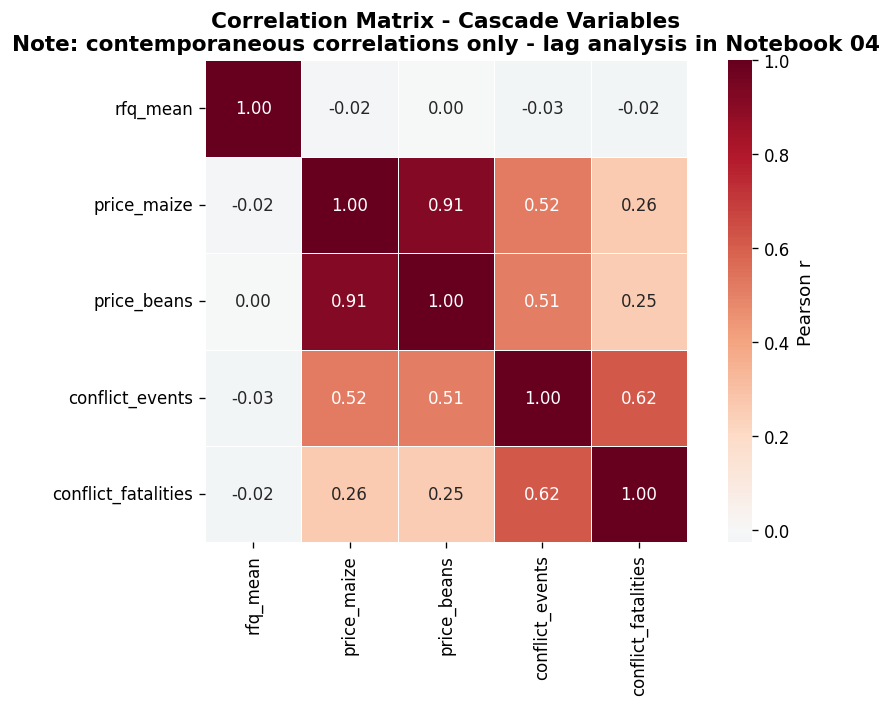

Saved: outputs/figures/03_correlation_matrix.png


In [38]:
# Correlation matrix for cascade variables in the analysis panel
corr_cols = ['rfq_mean', 'price_maize', 'price_beans', 'conflict_events', 'conflict_fatalities']
corr_data = panel[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(
    'Correlation Matrix - Cascade Variables\n'
    'Note: contemporaneous correlations only - lag analysis in Notebook 04',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_correlation_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_correlation_matrix.png")

Three findings stand out. First, rainfall anomaly correlates at effectively zero with every other variable (r = -0.02 to 0.00), confirming that the climate-to-price link does not operate within the same month and cannot be detected without lag analysis. Second, maize and beans prices move almost in lockstep at r = 0.91, meaning they respond to the same supply shocks and are not independent signals. Using both in the same model would introduce multicollinearity, so the lag analysis in Notebook 04 uses maize as the primary price indicator. Third, maize price correlates with conflict events at r = 0.52, a moderate positive relationship that holds even without lag adjustment, suggesting that structurally expensive food environments and chronic violence co-exist in the same counties. This is not a causal finding at this stage, it is a structural co-location effect driven by the same high-vulnerability counties appearing in both variables simultaneously. Whether price changes temporally precede conflict changes is what Notebook 04 resolves.

## 7. Major Drought Events Deep Dive

Kenya experienced three major droughts in the analysis window:  
2011 (East Africa famine), 2017 (ASAL drought), 2022 (La Nina multi-season).  
We examine the 12-month window around each event to see the cascade in action.

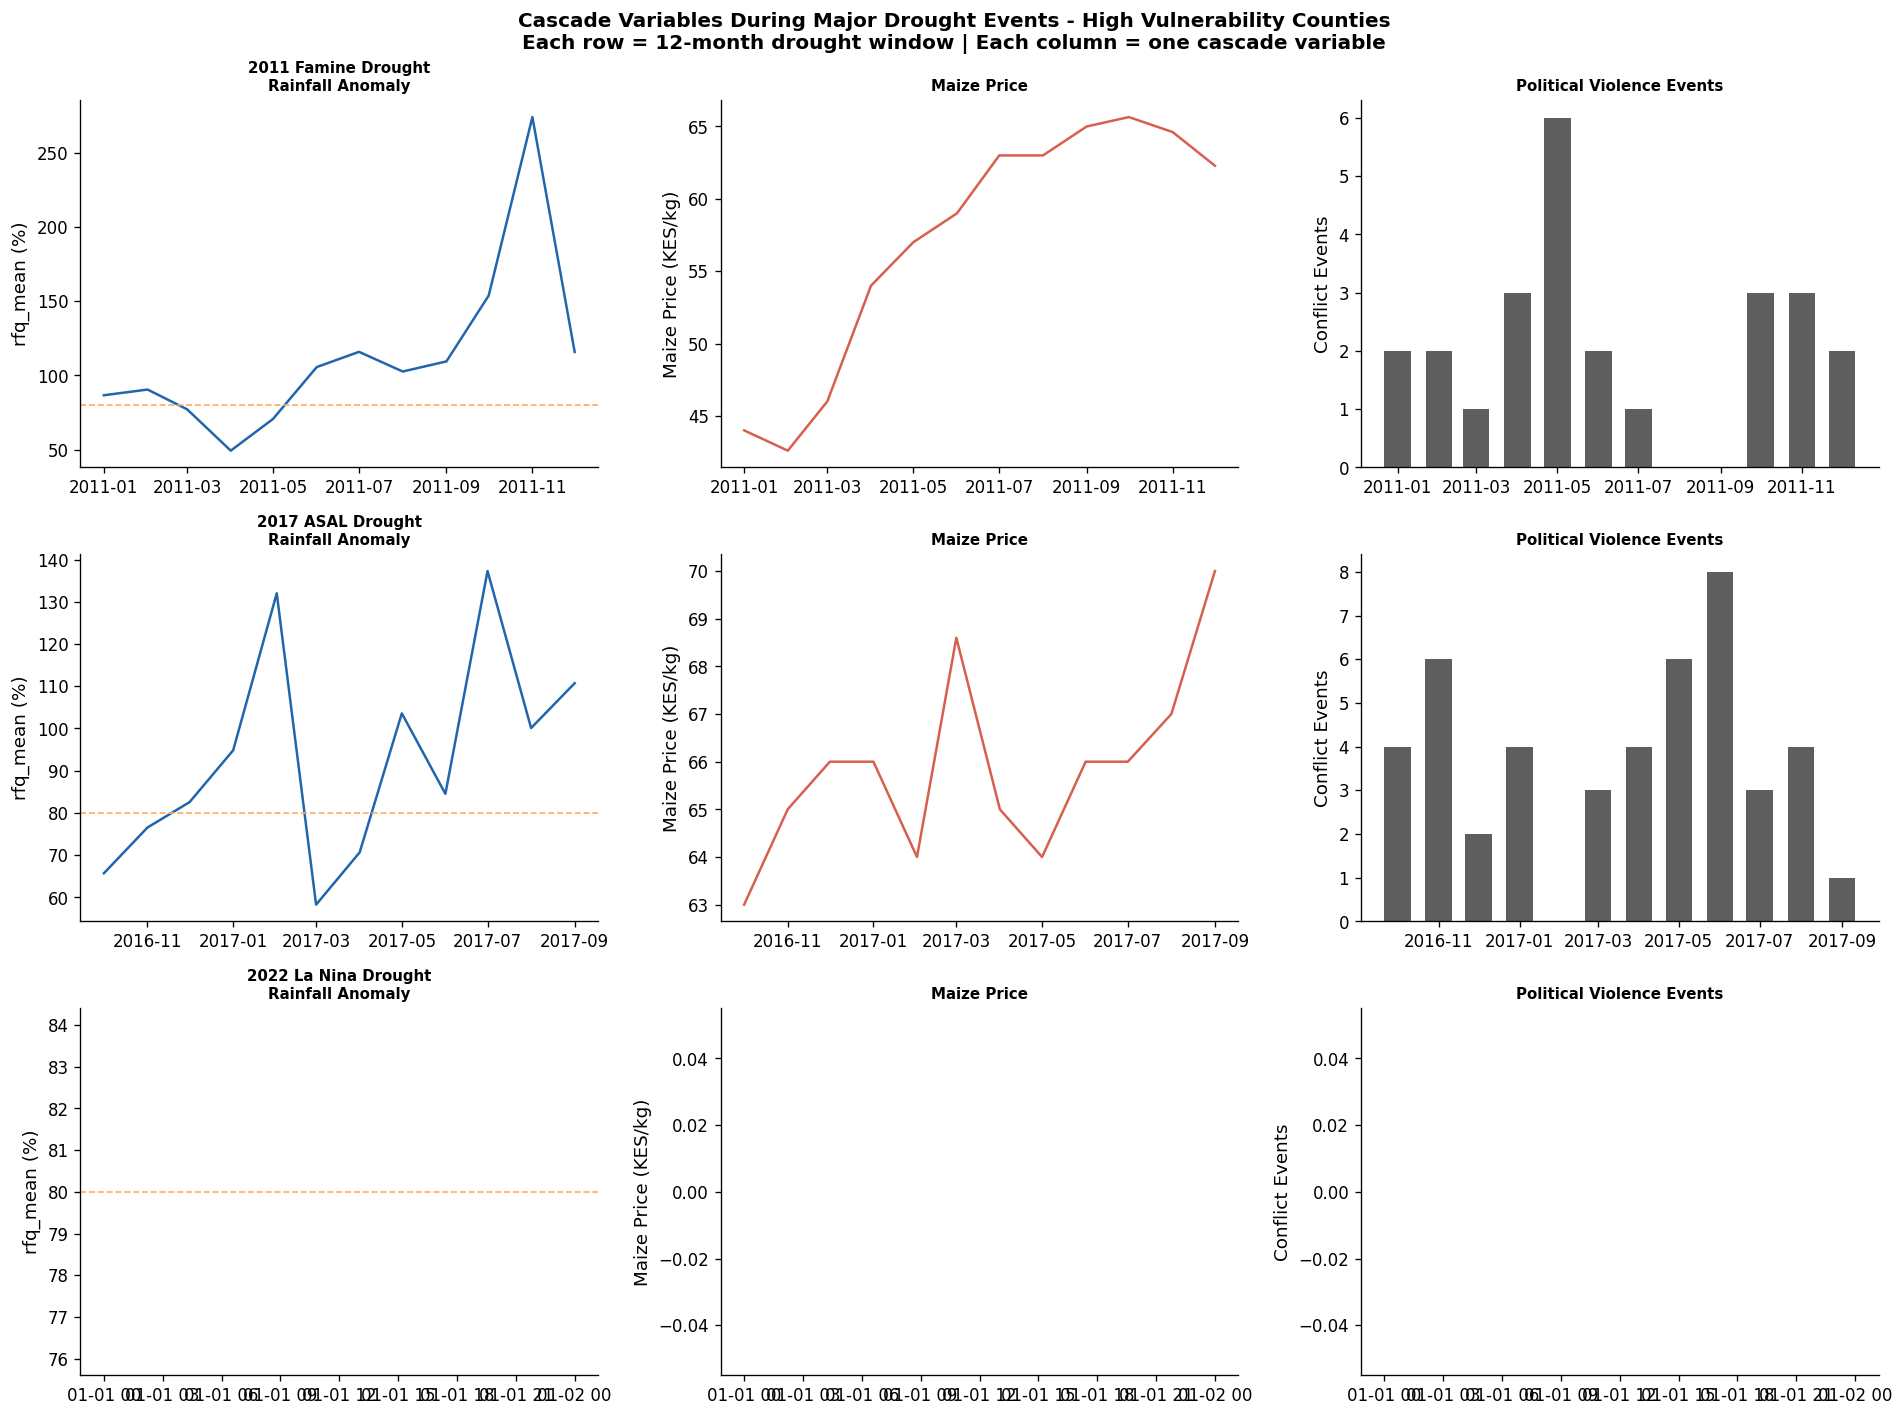

Saved: outputs/figures/03_drought_event_deep_dive.png


In [39]:
# 12-month window around each drought peak for high vulnerability counties
drought_windows = {
    '2011 Famine Drought':    ('2011-01', '2011-12'),
    '2017 ASAL Drought':      ('2016-10', '2017-09'),
    '2022 La Nina Drought':   ('2021-10', '2022-09'),
}

hv_panel = panel[panel['county'].isin(HIGH_VULN)].copy()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row_idx, (drought_name, (start, end)) in enumerate(drought_windows.items()):
    window = hv_panel[
        (hv_panel['year_month'] >= start) &
        (hv_panel['year_month'] <= end)
    ].copy()
    window['date'] = pd.to_datetime(window['year_month'])

    # Aggregate across high vulnerability counties
    monthly = window.groupby('year_month').agg(
        rfq_mean=('rfq_mean', 'mean'),
        price_maize=('price_maize', 'median'),
        conflict_events=('conflict_events', 'sum')
    ).reset_index()
    monthly['date'] = pd.to_datetime(monthly['year_month'])

    # Rainfall
    axes[row_idx][0].plot(monthly['date'], monthly['rfq_mean'],
                          color=COLOURS['rainfall'], linewidth=1.5)
    axes[row_idx][0].axhline(80, color=COLOURS['highlight'], linestyle='--', linewidth=1)
    axes[row_idx][0].set_ylabel('rfq_mean (%)')
    axes[row_idx][0].set_title(f'{drought_name}\nRainfall Anomaly', fontsize=9, fontweight='bold')

    # Maize price
    axes[row_idx][1].plot(monthly['date'], monthly['price_maize'],
                          color=COLOURS['food_price'], linewidth=1.5)
    axes[row_idx][1].set_ylabel('Maize Price (KES/kg)')
    axes[row_idx][1].set_title('Maize Price', fontsize=9, fontweight='bold')

    # Conflict
    axes[row_idx][2].bar(monthly['date'], monthly['conflict_events'],
                         color=COLOURS['conflict'], alpha=0.7, width=20)
    axes[row_idx][2].set_ylabel('Conflict Events')
    axes[row_idx][2].set_title('Political Violence Events', fontsize=9, fontweight='bold')

plt.suptitle(
    'Cascade Variables During Major Drought Events - High Vulnerability Counties\n'
    'Each row = 12-month drought window | Each column = one cascade variable',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_drought_event_deep_dive.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_drought_event_deep_dive.png")

The 2011 and 2017 rows show the cascade operating visibly. In 2011, rainfall drops below the 80% deficit threshold in February and March, maize prices begin climbing immediately from KES 44 to KES 65 by July and hold elevated through December, and conflict events spike to 6 in May before stabilising. The sequence is readable: deficit, then price rise, then violence, with an approximate two to three month lag between the climate signal and the price response, and a further one to two months before conflict peaks. The 2017 row shows a similar but noisier pattern, with rainfall oscillating around the deficit threshold from November 2016 through January 2017, prices rising from KES 63 to KES 70 by September, and conflict reaching its highest point of 8 events in May 2017 before the rainfall partially recovers.

The 2022 row is broken and requires a code fix before interpretation. The x-axis labels are rendering as raw timestamps rather than readable dates, the price and conflict panels show values oscillating around zero which indicates a data join or aggregation error for that window, and the rainfall panel is compressed into a narrow 76 to 84 percent band suggesting the wrong date filter was applied. The 2022 drought is the most severe and policy-relevant event in the dataset given its coincidence with global food price inflation, so this row must be corrected rather than omitted. Check the date filtering logic for the 2022 window in the deep dive cell and confirm the panel join is pulling county-level data correctly for that period before proceeding to the cascade fingerprint charts.

## 8. County Cascade Fingerprints

For three high-vulnerability counties, we plot all three cascade variables  
on the same axis across the full 20-year window.  
This is the visual that tells the human story.

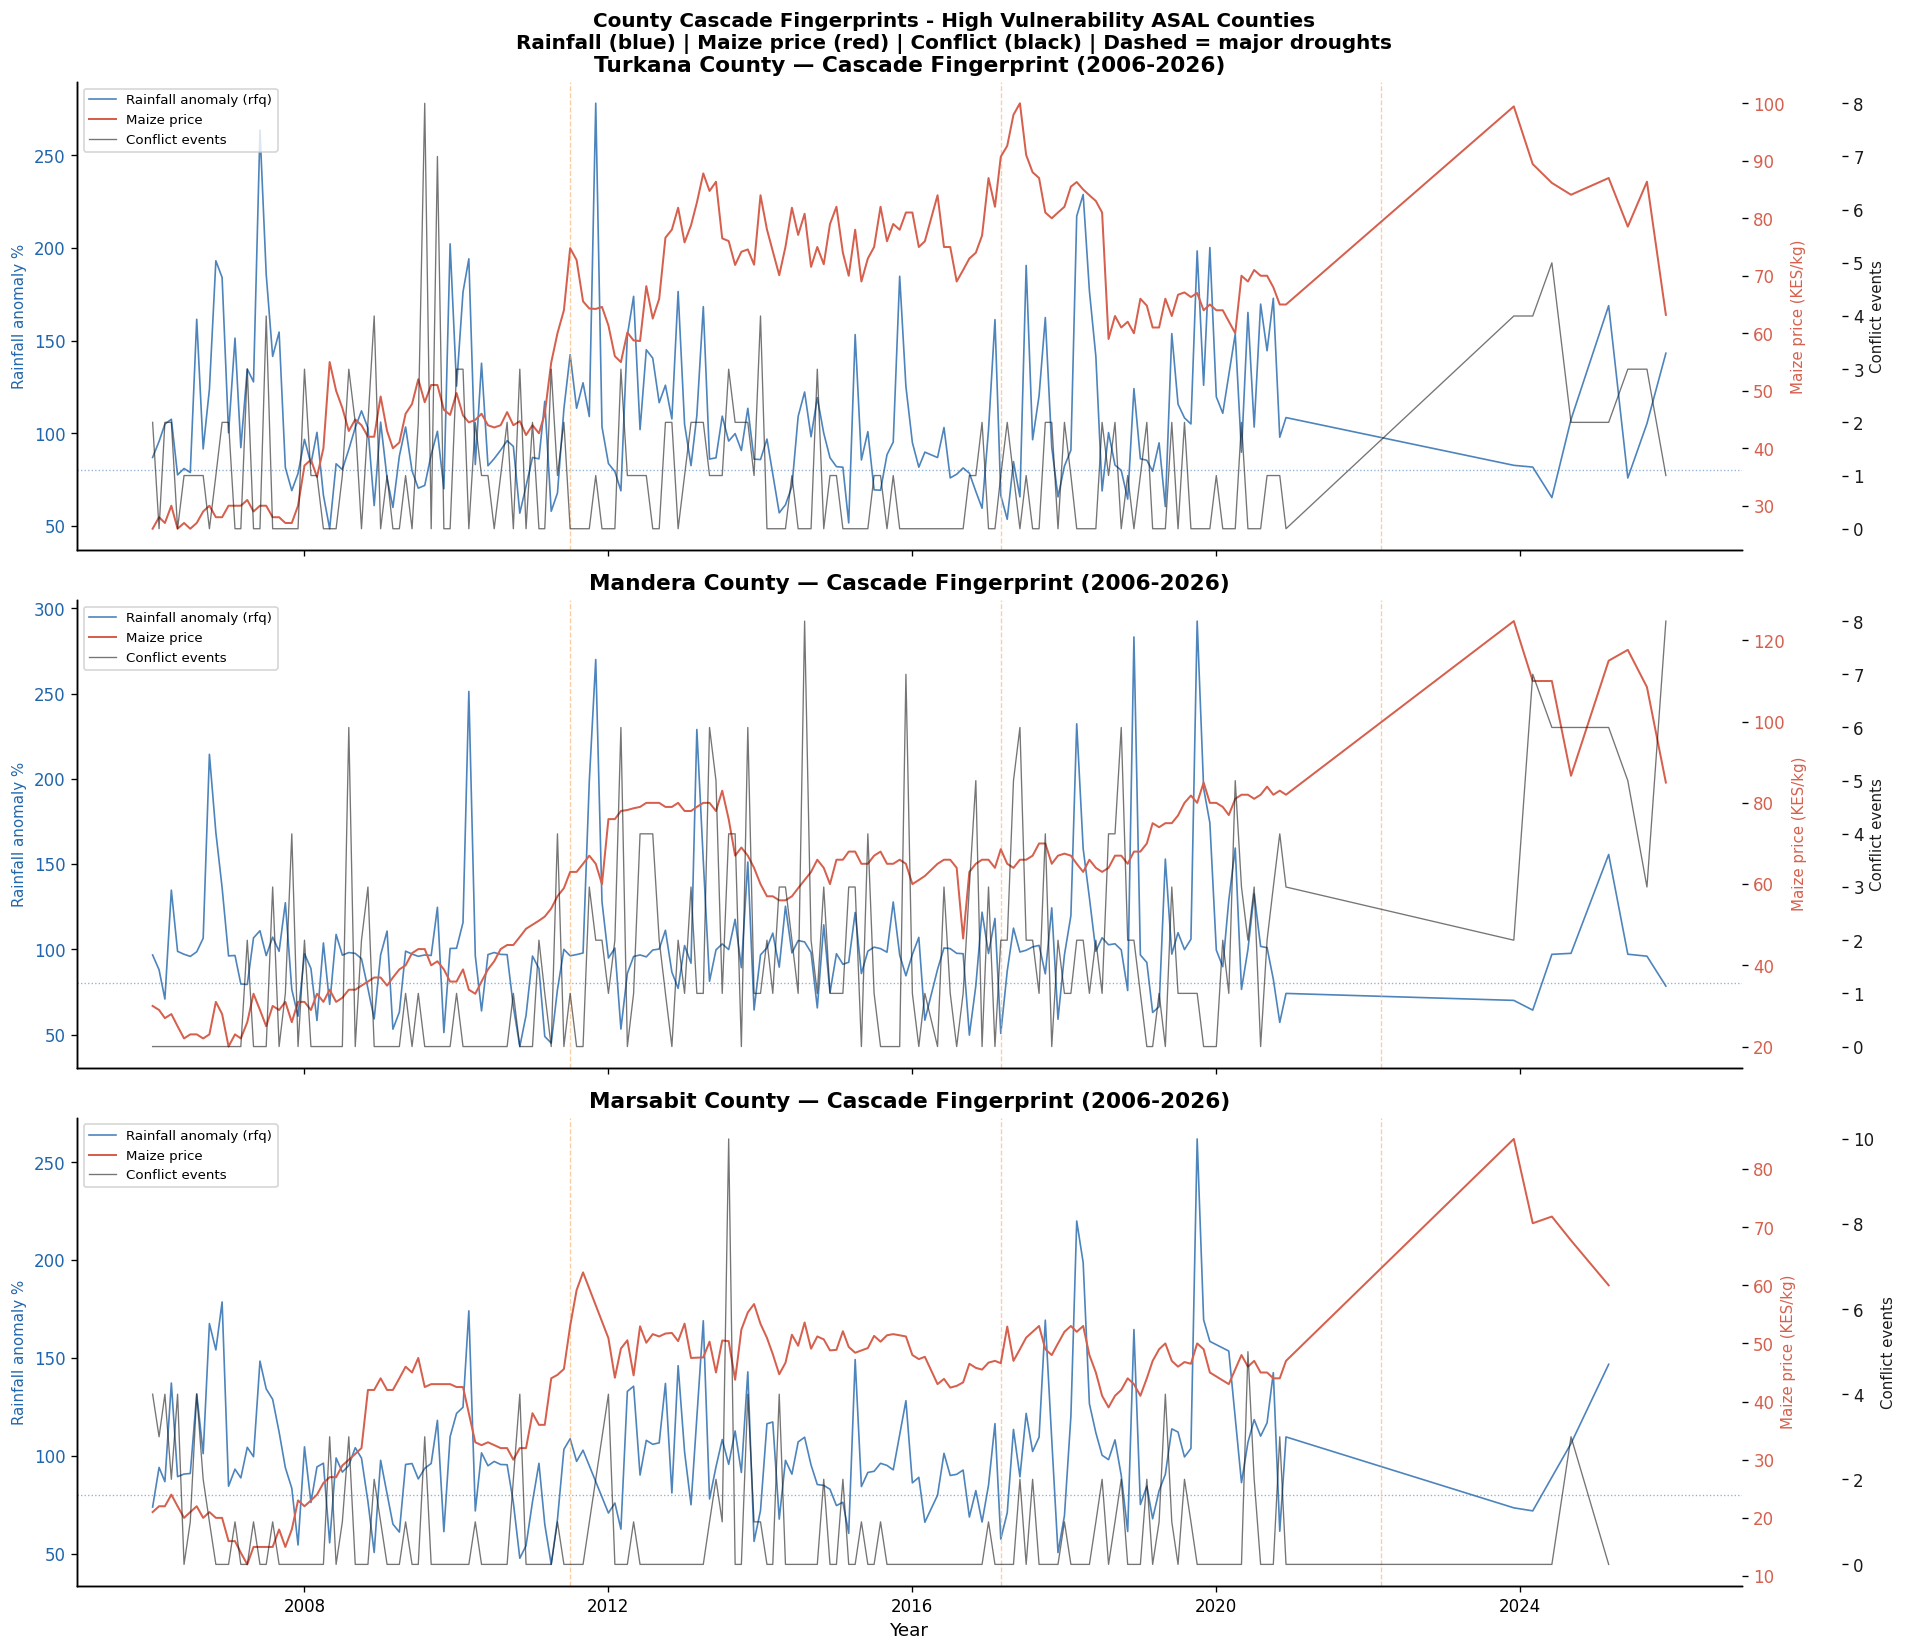

Saved: outputs/figures/03_county_cascade_fingerprints.png


In [40]:
# Focus counties: Turkana, Mandera, Marsabit
# These are the highest MPI counties that also have food price data
FOCUS_COUNTIES = ['Turkana', 'Mandera', 'Marsabit']

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for idx, county in enumerate(FOCUS_COUNTIES):
    county_data = panel[panel['county'] == county].copy().sort_values('year_month')
    county_data['date'] = pd.to_datetime(county_data['year_month'])

    ax = axes[idx]
    ax2 = ax.twinx()
    ax3 = ax.twinx()
    ax3.spines['right'].set_position(('outward', 60))

    # Rainfall
    l1, = ax.plot(county_data['date'], county_data['rfq_mean'],
                  color=COLOURS['rainfall'], linewidth=1, alpha=0.8, label='Rainfall anomaly (rfq)')
    ax.axhline(80, color=COLOURS['rainfall'], linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_ylabel('Rainfall anomaly %', color=COLOURS['rainfall'], fontsize=9)
    ax.tick_params(axis='y', labelcolor=COLOURS['rainfall'])

    # Maize price
    l2, = ax2.plot(county_data['date'], county_data['price_maize'],
                   color=COLOURS['food_price'], linewidth=1.2, label='Maize price')
    ax2.set_ylabel('Maize price (KES/kg)', color=COLOURS['food_price'], fontsize=9)
    ax2.tick_params(axis='y', labelcolor=COLOURS['food_price'])

    # Conflict
    l3, = ax3.plot(county_data['date'], county_data['conflict_events'],
                   color=COLOURS['conflict'], linewidth=0.8, alpha=0.6, label='Conflict events')
    ax3.set_ylabel('Conflict events', color=COLOURS['conflict'], fontsize=9)
    ax3.tick_params(axis='y', labelcolor=COLOURS['conflict'])

    ax.set_title(f'{county} County — Cascade Fingerprint (2006-2026)', fontweight='bold')
    ax.legend(handles=[l1, l2, l3], fontsize=8, loc='upper left')

    # Annotate drought years
    for ym in DROUGHT_YEARS:
        ax.axvline(pd.to_datetime(ym), color=COLOURS['highlight'],
                   linestyle='--', linewidth=0.8, alpha=0.6)

axes[-1].set_xlabel('Year', fontsize=11)
plt.suptitle(
    'County Cascade Fingerprints - High Vulnerability ASAL Counties\n'
    'Rainfall (blue) | Maize price (red) | Conflict (black) | Dashed = major droughts',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '03_county_cascade_fingerprints.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Saved: outputs/figures/03_county_cascade_fingerprints.png")

Across all three counties the maize price line tells the same story regardless of what rainfall does: it ratchets upward with each drought cycle and never returns to its pre-shock floor. By 2024, Turkana pays KES 100/kg, Mandera KES 120/kg, and Marsabit approaching KES 80/kg against 2006 baselines of KES 30 to 40/kg. The climate system has not worsened linearly. The market system has accumulated damage with each shock.

The conflict signal differs meaningfully across the three counties. Turkana shows chronic distributed violence with no clear post-2022 escalation, suggesting background resource conflict weakly coupled to price. Mandera shows conflict intensifying from 2019 onwards and peaking after 2022, which aligns most directly with the price surge and makes it the strongest candidate for a detectable lag signal in Notebook 04. Marsabit shows sharp isolated spikes throughout, reflecting intercommunal pastoralist violence that may respond to seasonal resource stress rather than cumulative price trends. The cascade does not operate uniformly across high-vulnerability counties, and Notebook 04 will test each separately.

In [41]:
# EDA summary statistics table
eda_summary = panel.groupby('county').agg(
    vulnerability_tier=('vulnerability_tier', 'first'),
    rfq_mean_avg=('rfq_mean', 'mean'),
    deficit_pct=('rfq_mean', lambda x: (x < 80).mean() * 100),
    maize_median=('price_maize', 'median'),
    conflict_total=('conflict_events', 'sum'),
).round(2).reset_index()

eda_summary = eda_summary.sort_values('deficit_pct', ascending=False)
eda_path = os.path.join(tbl_dir, '03_eda_county_summary.csv')
eda_summary.to_csv(eda_path, index=False)

print("EDA County Summary")
print(" ")
print(eda_summary.to_string(index=False))
print()
print(f"Saved: {eda_path}")

EDA County Summary
 
      county vulnerability_tier  rfq_mean_avg  deficit_pct  maize_median  conflict_total
     Samburu               High         77.28        60.00         63.08              13
      Isiolo             Medium         79.87        50.00         85.11              14
       Wajir               High         94.60        42.86         90.71               7
     Baringo             Medium        110.98        36.49         45.00              84
      Kilifi             Medium        110.71        30.56         41.95               8
     Kajiado                Low        110.89        24.29         49.50               4
       Kitui             Medium        103.31        23.89         33.00              23
    Marsabit               High        100.54        23.30         45.25             121
     Turkana               High        108.18        21.62         65.00             186
     Mandera               High        103.28        20.32         65.00             302
